# Домашнее задание: Создание Multi-Task классификатора токсичности (Энкодеры)

Добро пожаловать на продвинутое домашнее задание по трансформерным энкодерам!

В этом задании вам предстоит пройти весь путь создания production-ready NLP модели: от формализации бизнес-задачи и сбора данных до обучения Multi-Task энкодера с ранней остановкой и деплоя готового решения на Hugging Face.

Вам предстоит создать модель, которая будет одновременно предсказывать три независимых класса токсичности для одного текста:
1. Ненормативная лексика (Profanity)
2. Угрозы (Threats)
3. Запросы на нарушение закона (Illegal acts, например, "как создать бомбу")

---

## Часть 1: Формализация задачи (10 баллов)

Представьте, что вы работаете в социальной сети или платформе для общения. Бизнес пришел к вам с запросом: "Нам нужно автоматически фильтровать и помечать токсичные комментарии пользователей по трем категориям, чтобы модераторы могли быстрее реагировать на угрозы, а алгоритмы могли автоматически скрывать мат".

**Задание 1.1: Бизнес-метрики (3 балла)**
Предложите 2-3 бизнес-метрики, которые будет оптимизировать ваше решение. Оцифруйте их (например, "снижение времени реакции модератора на...").


In [ ]:
# TODO: Опишите бизнес-метрики
# снижение времени реакции модератора на токсичные комментари
# снижение количества модераторов за счёт автоматизации поиска
# снижение количества жалоб и репутационных потерь из-за токсичных комментариев

**Задание 1.2: Сведение к ML-задаче (3 балла)**
Сведите бизнес-задачу к ML-задаче. Опишите:
- Тип задачи (какая это классификация?)
- Объект (что подается на вход?)
- Метки (в каком формате модель выдает ответ?)


In [ ]:
# TODO: Опишите ML-задачу
# три бинарных классификации, со степенью уверенности(думаю это будет выгоднее чем просто классификация, потому что ответы могу содержать несколько классов + можем работать с отдельными с классами)
# комментарий пользователя, то есть текст
# 3 класса и степень уверенности каждого(от 0 до 1)

**Задание 1.3: ML-метрики (4 балла)**
Предложите оффлайн метрики для оценки качества модели. Учтите, что классы могут быть сильно несбалансированы (мат встречается часто, а запросы на нарушение закона — редко).


In [ ]:
# TODO: Опишите ML-метрики
# полнота(самое важное), чтобы не пропустить ни одного токсичного комментария
# точность, чтобы лучше определять классы и справедливвые наказания за них
#

---

## Часть 2: Сбор, очистка и аналитика датасета (15 баллов)

Вам необходимо собрать датасет для обучения. Вы можете использовать готовые открытые датасеты (например, `Kaggle Toxic Comment Classification Challenge`, переведенный на русский, или русскоязычные датасеты вроде `ru_toxic_comments`).

**Задание 2.1: Сбор и очистка (7 баллов)**
Загрузите данные (минимум 5000 примеров). Очистите текст от ссылок, HTML-тегов и лишних символов. Приведите метки к формату трех бинарных колонок: `profanity`, `threat`, `illegal`.


In [6]:
!pip install pandas datasets kagglehub
!pip install -q kagglehub

Собрал датасет с 3 источников

https://www.kaggle.com/datasets/alexandersemiletov/toxic-russian-comments
для угроз и ненормативной лексики

https://huggingface.co/datasets/s-nlp/ru_paradetox_toxicity для нетоксичный примеров

https://huggingface.co/datasets/NiGuLa/Russian_Sensitive_Topics для незаконных

In [5]:
import pandas as pd
import re
from datasets import load_dataset
import kagglehub
import os

df = pd.DataFrame(columns=['text', 'profanity', 'threat', 'illegal'])

# Нетоксичные с https://huggingface.co/datasets/s-nlp/ru_paradetox_toxicity
paradetox = load_dataset("s-nlp/ru_paradetox_toxicity", split="train").to_pandas()
paradetox = paradetox[paradetox['toxic'] == False]
paradetox = paradetox[['neutral']].rename(columns={'neutral': 'text'})
paradetox['profanity'] = paradetox['threat'] = paradetox['illegal'] = 0
df = pd.concat([df, paradetox], ignore_index=True)

# illegal с https://huggingface.co/datasets/NiGuLa/Russian_Sensitive_Topics
sens = load_dataset("NiGuLa/Russian_Sensitive_Topics", split="train").to_pandas()
sens['offline_crime'] = sens['offline_crime'].fillna(0).astype(int)
sens['online_crime'] = sens['online_crime'].fillna(0).astype(int)
sens['illegal'] = (sens['offline_crime'] | sens['online_crime']).astype(int)
sens = sens[sens['illegal'] == 1][['text']].copy()
sens['profanity'] = sens['threat'] = 0
sens['illegal'] = 1
df = pd.concat([df, sens], ignore_index=True)

# profanity, threat с https://www.kaggle.com/datasets/alexandersemiletov/toxic-russian-comments
path = kagglehub.dataset_download("alexandersemiletov/toxic-russian-comments")
with open(os.path.join(path, 'dataset.txt'), 'r', encoding='utf-8') as f:
    data = []
    for line in f:
        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            label = parts[0].replace('__label__', '')
            text = parts[1]
            data.append((text, label))
kag = pd.DataFrame(data, columns=['text', 'label'])
kag['profanity'] = (kag['label'] == 'OBSCENITY').astype(int)
kag['threat'] = (kag['label'] == 'THREAT').astype(int)
kag['illegal'] = 0
kag = kag[(kag['profanity'] == 1) | (kag['threat'] == 1)]
kag = kag[['text', 'profanity', 'threat', 'illegal']]
df = pd.concat([df, kag], ignore_index=True)

# Очистка
def clean(t):
    if not isinstance(t, str): return ""
    t = re.sub(r'<.*?>|https?://\S+|www\.\S+|@\S+|#\S+', ' ', t)
    t = re.sub(r'[^а-яА-Яa-zA-Z0-9\s\.!?,;:\-]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['text'] = df['text'].apply(clean)
df = df[df['text'].str.len() > 0].reset_index(drop=True)

print("Всего:", len(df))
print("profanity:", df['profanity'].sum())
print("threat:   ", df['threat'].sum())
print("illegal:  ", df['illegal'].sum())

print("\nЧистые (3):")
for t in df[(df['profanity']==0)&(df['threat']==0)&(df['illegal']==0)]['text'].head(3):
    print(t)

print("\nProfanity (3):")
for t in df[df['profanity']==1]['text'].head(3):
    print(t)

print("\nThreat (3):")
for t in df[df['threat']==1]['text'].head(3):
    print(t)

print("\nIllegal (3):")
for t in df[df['illegal']==1]['text'].head(3):
    print(t)

README.md:   0%|          | 0.00/2.78k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/656k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6354 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/2.30k [00:00<?, ?B/s]

sensitive_topics.csv:   0%|          | 0.00/9.47M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33303 [00:00<?, ? examples/s]

100%|██████████| 12.0M/12.0M [00:02<00:00, 6.20MB/s]

Extracting files...


Всего: 15269
profanity: 2245
threat:    5460
illegal:   2716

Чистые (3):
Вот и довели себя до сахарного диабета второго типа
Мойщик машину пеной залил, а хозяин виноват? По-моему ты ошибаешься.
Какой совет может дать эта девушка?

Profanity (3):
эти генеральши знают где соснуть и раздвинуть зад и передок ,позор страны
полизал бы и всунул
моя любит попа игрушкой секс с в попку мою класс

Threat (3):
надо было его собаку на заборе повесить ,жалко скотинку конечно но это было бы предсказание...
давайте его ;растреляем; в театре на спектакле гнилыми помидорами и все!!
вот растрелять бы этих богослужителей, грабить доверчивых , и одеваются в золото!

Illegal (3):
да мужиков пиздят некоторые бабы похлеще
Как баба и словно мужика режут
То есть мужиков бить можно а баб нельзя


**Задание 2.2: Аналитика и дисбаланс (8 баллов)**
Постройте графики распределения классов (bar chart). Оцените дисбаланс. Постройте матрицу корреляции между классами (пересекаются ли угрозы с матом?).


/tmp/ipykernel_10225/1876679030.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


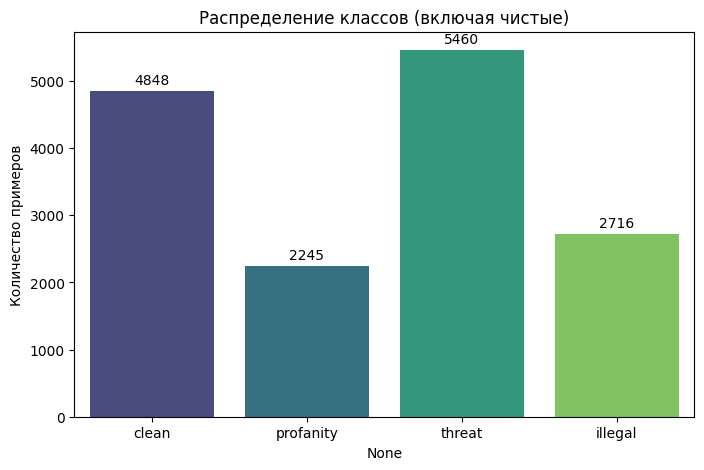

Доли классов:
clean:     31.75%
profanity: 14.70%
threat:    35.76%
illegal:   17.79%


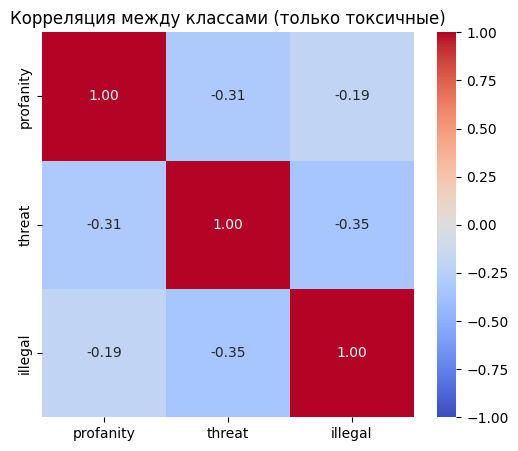


Пересечения классов (profanity, threat, illegal):
   profanity  threat  illegal  count
0          0       0        0   4848
1          0       0        1   2716
2          0       1        0   5460
3          1       0        0   2245


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# TODO: Аналитика датасета

clean_count = len(df[(df['profanity']==0) & (df['threat']==0) & (df['illegal']==0)])
counts = df[['profanity', 'threat', 'illegal']].sum()
class_counts = pd.Series({
    'clean': clean_count,
    'profanity': counts['profanity'],
    'threat': counts['threat'],
    'illegal': counts['illegal']
})

# График
plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Распределение классов (включая чистые)')
plt.ylabel('Количество примеров')
for i, v in enumerate(class_counts.values):
    plt.text(i, v+100, str(v), ha='center')
plt.show()

print("Доли классов:")
print(f"clean:     {class_counts['clean']/len(df):.2%}")
print(f"profanity: {class_counts['profanity']/len(df):.2%}")
print(f"threat:    {class_counts['threat']/len(df):.2%}")
print(f"illegal:   {class_counts['illegal']/len(df):.2%}")

# Матрица
corr = df[['profanity', 'threat', 'illegal']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Корреляция между классами (только токсичные)')
plt.show()

overlap = df.groupby(['profanity', 'threat', 'illegal']).size().reset_index(name='count')
print("\nПересечения классов (profanity, threat, illegal):")
print(overlap)

---

## Часть 3: Публикация датасета на Hugging Face (5 баллов)

**Задание 3.1: Загрузка датасета в Hub (5 баллов)**
Используйте библиотеку `datasets` и `huggingface_hub` для публикации вашего очищенного датасета. Обязательно создайте базовую Dataset Card.
*Подсказка: используйте `notebook_login()` для авторизации.*


In [24]:
from datasets import Dataset
from huggingface_hub import notebook_login

notebook_login()

card = """
# Русский датасет токсичных комментариев с разделением на profanity, threat, illegal"""
Dataset.from_pandas(df).push_to_hub("YuraYuyuyu/ru_classes_toxic")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/16 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  52%|#####2    |  528kB / 1.01MB            

CommitInfo(commit_url='https://huggingface.co/datasets/YuraYuyuyu/ru_classes_toxic/commit/5ba7d782e8ed39d05cb5a4acee90bd7afb116a1f', commit_message='Upload dataset', commit_description='', oid='5ba7d782e8ed39d05cb5a4acee90bd7afb116a1f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/YuraYuyuyu/ru_classes_toxic', endpoint='https://huggingface.co', repo_type='dataset', repo_id='YuraYuyuyu/ru_classes_toxic'), pr_revision=None, pr_num=None)

---

## Часть 4: Архитектура Multi-Task Энкодера (20 баллов)

Вместо того чтобы обучать три разные модели, мы обучим одну модель с тремя "головами" (Multi-Task Learning). Это сэкономит память и ускорит инференс.

**Задание 4.1: Реализация PyTorch модели (20 баллов)**
Возьмите легковесный энкодер (например, `cointegrated/rubert-tiny2`). Напишите класс-наследник `nn.Module`.
Модель должна:
1. Пропускать текст через энкодер.
2. Извлекать эмбеддинг `[CLS]` токена.
3. Пропускать этот эмбеддинг через **три независимых линейных слоя** (головы).
4. Возвращать три логита (до применения сигмоиды).


In [1]:
!pip install torch transformers

In [3]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class MultiTaskToxicityEncoder(nn.Module):
    def __init__(self, model_name="cointegrated/rubert-tiny2"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.head_profanity = nn.Linear(hidden_size, 1)
        self.head_threat = nn.Linear(hidden_size, 1)
        self.head_illegal = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [batch, hidden]
        return (self.head_profanity(cls_embedding),
                self.head_threat(cls_embedding),
                self.head_illegal(cls_embedding))

---

## Часть 5: Обучение с ранней остановкой (Early Stopping) (20 баллов)

**Задание 5.1: Тренировочный цикл (20 баллов)**
Напишите цикл обучения.
- Используйте `BCEWithLogitsLoss` для каждой головы. Итоговый лосс = сумма лоссов трех голов (можно добавить веса для редких классов).
- Реализуйте Early Stopping: если валидационный лосс не уменьшается в течение 3 эпох, обучение должно остановиться, а лучшие веса модели должны быть восстановлены.


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
import copy

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc = self.tokenizer(text, truncation=True, padding='max_length',
                             max_length=128, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'][0],
            'attention_mask': enc['attention_mask'][0],
            'profanity': torch.tensor(self.labels[idx][0], dtype=torch.float),
            'threat': torch.tensor(self.labels[idx][1], dtype=torch.float),
            'illegal': torch.tensor(self.labels[idx][2], dtype=torch.float)
        }

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_labels = list(zip(train_df['profanity'], train_df['threat'], train_df['illegal']))
val_labels = list(zip(val_df['profanity'], val_df['threat'], val_df['illegal']))

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

train_dataset = ToxicDataset(train_df['text'].values, train_labels, tokenizer)
val_dataset = ToxicDataset(val_df['text'].values, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiTaskToxicityEncoder().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

best_loss = float('inf')
patience = 3
wait = 0
best_state = None

for epoch in range(10):
    model.train()
    train_loss = 0
    for batch in train_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        prof = batch['profanity'].to(device)
        threat = batch['threat'].to(device)
        illegal = batch['illegal'].to(device)

        p, t, i = model(ids, mask)
        loss = (criterion(p.squeeze(), prof) +
                criterion(t.squeeze(), threat) +
                criterion(i.squeeze(), illegal))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            prof = batch['profanity'].to(device)
            threat = batch['threat'].to(device)
            illegal = batch['illegal'].to(device)

            p, t, i = model(ids, mask)
            loss = (criterion(p.squeeze(), prof) +
                    criterion(t.squeeze(), threat) +
                    criterion(i.squeeze(), illegal))
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}: Train Loss={avg_train:.4f}, Val Loss={avg_val:.4f}")

    if avg_val < best_loss:
        best_loss = avg_val
        wait = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Best model restored")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1: Train Loss=0.8653, Val Loss=0.4604
Epoch 2: Train Loss=0.3867, Val Loss=0.3169
Epoch 3: Train Loss=0.2583, Val Loss=0.2715
Epoch 4: Train Loss=0.1847, Val Loss=0.2486
Epoch 5: Train Loss=0.1341, Val Loss=0.2449
Epoch 6: Train Loss=0.1015, Val Loss=0.2426
Epoch 7: Train Loss=0.0758, Val Loss=0.2701
Epoch 8: Train Loss=0.0557, Val Loss=0.2651
Epoch 9: Train Loss=0.0452, Val Loss=0.2638
Early stopping at epoch 9
Best model restored


---

## Часть 6: Оценка, пороги и визуализация ошибок (20 баллов)

Модель выдает вероятности. Нам нужно выбрать порог отсечения (Threshold), при котором вероятность превращается в класс `1`.

**Задание 6.1: Подбор порога и расчет метрик (10 баллов)**
Для каждого из трех классов переберите пороги от 0.1 до 0.9. Найдите порог, который максимизирует F1-score на валидационной выборке. Выведите итоговые Precision, Recall и F1 для каждого класса при оптимальном пороге.


In [11]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, f1_score

model.eval()
y_true = {'profanity': [], 'threat': [], 'illegal': []}
y_pred = {'profanity': [], 'threat': [], 'illegal': []}

with torch.no_grad():
    for batch in val_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)

        p, t, i = model(ids, mask)
        p = torch.sigmoid(p).cpu().numpy().flatten()
        t = torch.sigmoid(t).cpu().numpy().flatten()
        i = torch.sigmoid(i).cpu().numpy().flatten()

        y_true['profanity'].extend(batch['profanity'].numpy())
        y_true['threat'].extend(batch['threat'].numpy())
        y_true['illegal'].extend(batch['illegal'].numpy())
        y_pred['profanity'].extend(p)
        y_pred['threat'].extend(t)
        y_pred['illegal'].extend(i)

thresholds = np.arange(0.1, 0.95, 0.05)
best = {}

for cls in ['profanity', 'threat', 'illegal']:
    best_f1 = 0
    best_thr = 0.5
    for thr in thresholds:
        pred_bin = (np.array(y_pred[cls]) >= thr).astype(int)
        f1 = f1_score(y_true[cls], pred_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    pred_bin = (np.array(y_pred[cls]) >= best_thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true[cls], pred_bin,
                                                        average='binary', zero_division=0)
    best[cls] = {'threshold': best_thr, 'precision': prec, 'recall': rec, 'f1': f1}

for cls in best:
    print(f"{cls}: порог={best[cls]['threshold']:.2f}, Precision={best[cls]['precision']:.4f}, Recall={best[cls]['recall']:.4f}, F1={best[cls]['f1']:.4f}")

profanity: порог=0.55, Precision=0.9509, Recall=0.9595, F1=0.9552
threat: порог=0.35, Precision=0.9520, Recall=0.9727, F1=0.9622
illegal: порог=0.45, Precision=0.9014, Recall=0.8876, F1=0.8944


**Задание 6.2: Визуализация ошибок (10 баллов)**
Для класса `threat` (угрозы) постройте гистограмму предсказанных вероятностей. Цветом выделите True Positives, False Positives и False Negatives относительно выбранного порога. Это поможет бизнесу понять, насколько модель "уверена" когда ошибается.

**Пример хорошей визуализации:**
![image.png](attachment:image.png)


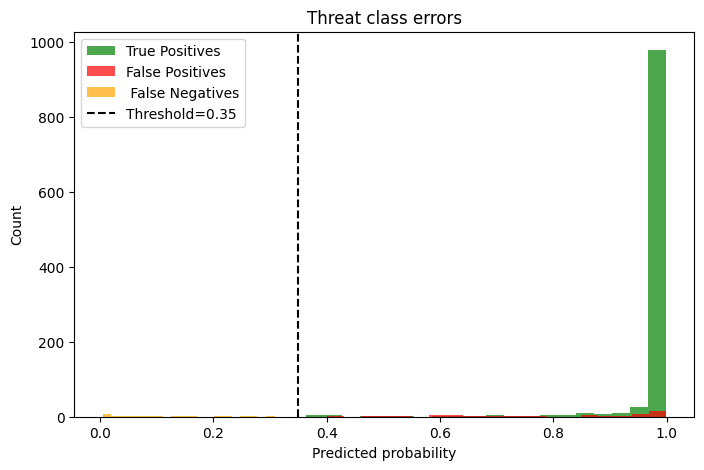

In [12]:
import matplotlib.pyplot as plt
import numpy as np

true = np.array(y_true['threat'])
pred = np.array(y_pred['threat'])
thr = best['threat']['threshold']

tp = (pred >= thr) & (true == 1)
fp = (pred >= thr) & (true == 0)
fn = (pred < thr) & (true == 1)

plt.figure(figsize=(8,5))
plt.hist(pred[tp], bins=20, alpha=0.7, label='True Positives', color='green')
plt.hist(pred[fp], bins=20, alpha=0.7, label='False Positives', color='red')
plt.hist(pred[fn], bins=20, alpha=0.7, label=' False Negatives', color='orange')
plt.axvline(x=thr, color='black', linestyle='--', label=f'Threshold={thr:.2f}')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Threat class errors')
plt.legend()
plt.show()

---

## Часть 7: Инференс и ручное тестирование (10 баллов)

**Задание 7.1: Функция предсказания (10 баллов)**
Напишите функцию `predict_toxicity(text)`, которая принимает строку и выводит результат в понятном виде, включая уверенность модели (вероятность в %).
Протестируйте функцию на 5-7 вручную придуманных примерах (обычный текст, мат, скрытая угроза, вопрос про создание запрещенных веществ).


In [15]:
def predict_toxicity(text):
    inputs = tokenizer(text, truncation=True, padding='max_length',
                       max_length=128, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        logits_p, logits_t, logits_i = model(input_ids, attention_mask)
        prob_p = torch.sigmoid(logits_p).item()
        prob_t = torch.sigmoid(logits_t).item()
        prob_i = torch.sigmoid(logits_i).item()

    prof = prob_p >= best['profanity']['threshold']
    threat = prob_t >= best['threat']['threshold']
    illegal = prob_i >= best['illegal']['threshold']

    print(f"Текст: {text}")
    print(f"Мат (profanity): {'ДА' if prof else 'НЕТ'} (уверенность: {prob_p:.1%})")
    print(f"Угроза (threat): {'ДА' if threat else 'НЕТ'} (уверенность: {prob_t:.1%})")
    print(f"Незаконное (illegal): {'ДА' if illegal else 'НЕТ'} (уверенность: {prob_i:.1%})")
    print("-" * 50)

texts = [
    "Привет! Отличная погода сегодня, пойдём гулять.",
    "Ты просто глупый, ничего не понимаешь!",
    "Всем привет! Как сделать наркотики в домашних условиях?",
    "Ты мне очень нравишься, давай встретимся?",
    "Завтра я приду к тебе домой и убью тебя.",
    "Это просто ужас, я не могу на это смотреть.",
    "Как собрать взрывное устройство из подручных средств?"
]

for text in texts:
    predict_toxicity(text)

Текст: Привет! Отличная погода сегодня, пойдём гулять.
Мат (profanity): НЕТ (уверенность: 0.8%)
Угроза (threat): НЕТ (уверенность: 0.2%)
Незаконное (illegal): НЕТ (уверенность: 0.2%)
--------------------------------------------------
Текст: Ты просто глупый, ничего не понимаешь!
Мат (profanity): НЕТ (уверенность: 0.4%)
Угроза (threat): НЕТ (уверенность: 0.3%)
Незаконное (illegal): НЕТ (уверенность: 0.2%)
--------------------------------------------------
Текст: Всем привет! Как сделать наркотики в домашних условиях?
Мат (profanity): НЕТ (уверенность: 0.1%)
Угроза (threat): НЕТ (уверенность: 0.1%)
Незаконное (illegal): ДА (уверенность: 64.8%)
--------------------------------------------------
Текст: Ты мне очень нравишься, давай встретимся?
Мат (profanity): НЕТ (уверенность: 1.8%)
Угроза (threat): НЕТ (уверенность: 0.2%)
Незаконное (illegal): НЕТ (уверенность: 0.1%)
--------------------------------------------------
Текст: Завтра я приду к тебе домой и убью тебя.
Мат (profanity): НЕТ (у

Модель не смогла определить как profanity

> Ты просто глупый, ничего не понимаешь!

также ей не хватило уверенности для определения как threat, скорее всего датасет неполный

> Завтра я приду к тебе домой и убью.



---

## Часть 8: Публикация модели на Hugging Face (10 баллов)

**Задание 8.1: Публикация модели (10 баллов)**
Сохраните веса вашей обученной модели и токенизатор. Загрузите их в свой репозиторий на Hugging Face Hub. Напишите небольшую Model Card, где укажете метрики и пример использования.


In [17]:
from huggingface_hub import notebook_login, HfApi, create_repo
import torch
import json
import os

notebook_login()

model_dir = "toxicity_model"
os.makedirs(model_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(model_dir, "pytorch_model.bin"))
tokenizer.save_pretrained(model_dir)

config = {
    "thresholds": {
        "profanity": best['profanity']['threshold'],
        "threat": best['threat']['threshold'],
        "illegal": best['illegal']['threshold']
    }
}
with open(os.path.join(model_dir, "config.json"), "w") as f:
    json.dump(config, f)

api = HfApi()
create_repo("YuraYuyuyu/toxicity-classifier", repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path=model_dir,
    repo_id="YuraYuyuyu/toxicity-classifier",
    repo_type="model"
)


CommitInfo(commit_url='https://huggingface.co/YuraYuyuyu/toxicity-classifier/commit/91c2b0e3d2a31f41274fa159c783d6aab432aded', commit_message='Upload folder using huggingface_hub', commit_description='', oid='91c2b0e3d2a31f41274fa159c783d6aab432aded', pr_url=None, repo_url=RepoUrl('https://huggingface.co/YuraYuyuyu/toxicity-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='YuraYuyuyu/toxicity-classifier'), pr_revision=None, pr_num=None)

---
**Поздравляем! Вы прошли полный цикл создания NLP-решения на базе трансформерных энкодеров.**
